In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
from multiprocessing import Pool, cpu_count
import time
import warnings
warnings.filterwarnings("ignore", category=FutureWarning, module="qutip")
# 加载评分函数
from cnot_spsa_solution import evaluate_pulse

# 设置中文字体支持
rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans']
rcParams['axes.unicode_minus'] = False


In [2]:

# 运行次数
iters_num = 100

# 加载脉冲
pulses_1 = np.load('results/pulses_closed.npy')
# pulses_2 = np.load('results/pulses_closed.npy')

phi = 0.0

print(f"开始并行评分 {iters_num} 次...")

# # 串行计算
# # evaluate_pulse 中评分器是并行
# results_1 = []
# results_2 = []
# for i in range(iters_num):
#     results_1.append(evaluate_pulse((pulses_1, False),computing_method='parallel'))
#     # results_2.append(evaluate_pulse((pulses_2, False),computing_method='parallel'))

# 准备并行计算参数
args_list_1 = [(pulses_1, False) for _ in range(iters_num)]


# 使用多进程并行计算
start_time = time.time()
with Pool() as pool:
    # 并行计算两组脉冲的评分
    # evaluate_pulse 中评分器是串行
    results_1 = pool.map(evaluate_pulse, args_list_1)
end_time = time.time()
print(f"并行计算耗时: {end_time - start_time:.2f} 秒")


# 提取结果
score_list_1 = [r[0] for r in results_1]
gate_error_list_1 = [r[1] for r in results_1]
gate_fidelity_list_1 = [r[2] for r in results_1]
leakage_list_1 = [r[3] for r in results_1]
penalty_list_1 = [r[4] for r in results_1]

# score_list_2 = [r[0] for r in results_2]
# gate_error_list_2 = [r[1] for r in results_2]
# gate_fidelity_list_2 = [r[2] for r in results_2]
# leakage_list_2 = [r[3] for r in results_2]
# penalty_list_2 = [r[4] for r in results_2]


# 打印统计信息
print("\n=== pulses_closed 统计信息 ===")
print(f"平均评分: {np.mean(score_list_1):.6f} ± {np.std(score_list_1):.6f}")
print(f"门错误: {np.mean(gate_error_list_1):.6f} ± {np.std(gate_error_list_1):.6f}")
print(f"门保真度: {np.mean(gate_fidelity_list_1):.6f} ± {np.std(gate_fidelity_list_1):.6f}")
print(f"泄漏: {np.mean(leakage_list_1):.6f} ± {np.std(leakage_list_1):.6f}")
print(f"惩罚: {np.mean(penalty_list_1):.6f} ± {np.std(penalty_list_1):.6f}")

# print("\n=== pulses_closed 统计信息 ===")
# print(f"平均评分: {np.mean(score_list_2):.6f} ± {np.std(score_list_2):.6f}")
# print(f"门错误: {np.mean(gate_error_list_2):.6f} ± {np.std(gate_error_list_2):.6f}")
# print(f"门保真度: {np.mean(gate_fidelity_list_2):.6f} ± {np.std(gate_fidelity_list_2):.6f}")
# print(f"泄漏: {np.mean(leakage_list_2):.6f} ± {np.std(leakage_list_2):.6f}")
# print(f"惩罚: {np.mean(penalty_list_2):.6f} ± {np.std(penalty_list_2):.6f}")


开始并行评分 100 次...
并行计算耗时: 6580.15 秒

=== pulses_closed 统计信息 ===
平均评分: 0.953563 ± 0.006014
门错误: 0.031829 ± 0.006716
门保真度: 0.968171 ± 0.006716
泄漏: 0.939297 ± 0.015797
惩罚: 0.762649 ± 0.000000


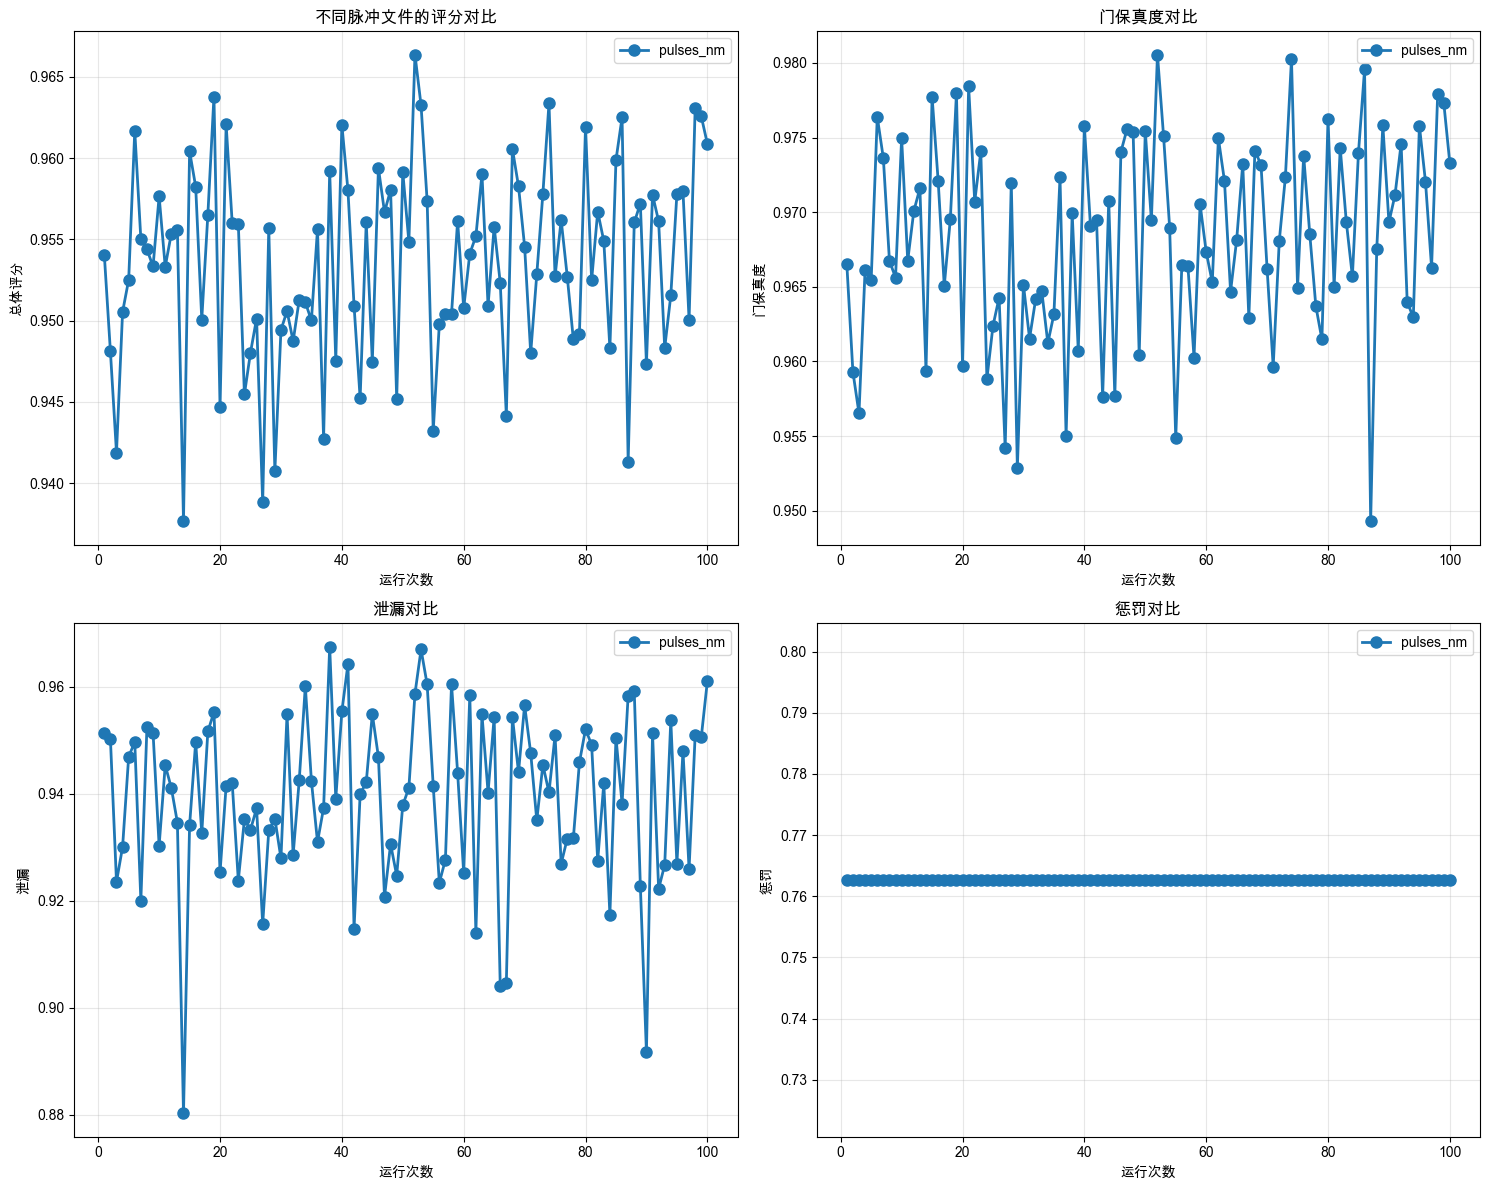

In [3]:

# 绘制详细结果
plt.figure(figsize=(15, 12))

# 子图1: 评分对比
plt.subplot(2, 2, 1)
plt.plot(range(1, iters_num+1), score_list_1, 'o-', label='pulses_nm', linewidth=2, markersize=8)
plt.xlabel('运行次数')
plt.ylabel('总体评分')
plt.title('不同脉冲文件的评分对比')
plt.legend()
plt.grid(True, alpha=0.3)

# 子图2: 门保真度对比
plt.subplot(2, 2, 2)
plt.plot(range(1, iters_num+1), gate_fidelity_list_1, 'o-', label='pulses_nm', linewidth=2, markersize=8)
plt.xlabel('运行次数')
plt.ylabel('门保真度')
plt.title('门保真度对比')
plt.legend()
plt.grid(True, alpha=0.3)

# 子图3: 泄漏对比
plt.subplot(2, 2, 3)
plt.plot(range(1, iters_num+1), leakage_list_1, 'o-', label='pulses_nm', linewidth=2, markersize=8)
plt.xlabel('运行次数')
plt.ylabel('泄漏')
plt.title('泄漏对比')
plt.legend()
plt.grid(True, alpha=0.3)

# 子图4: 惩罚对比
plt.subplot(2, 2, 4)
plt.plot(range(1, iters_num+1), penalty_list_1, 'o-', label='pulses_nm', linewidth=2, markersize=8)
plt.xlabel('运行次数')
plt.ylabel('惩罚')
plt.title('惩罚对比')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [4]:
np.max(score_list_1)

np.float64(0.966379844392311)

In [5]:

# # 绘制详细结果
# plt.figure(figsize=(15, 12))

# # 子图1: 评分对比
# plt.subplot(2, 2, 1)
# plt.plot(range(1, iters_num+1), score_list_2, 'o-', label='pulses_closed', linewidth=2, markersize=8)
# plt.xlabel('运行次数')
# plt.ylabel('总体评分')
# plt.title('不同脉冲文件的评分对比')
# plt.legend()
# plt.grid(True, alpha=0.3)

# # 子图2: 门保真度对比
# plt.subplot(2, 2, 2)
# plt.plot(range(1, iters_num+1), gate_fidelity_list_2, 'o-', label='pulses_closed', linewidth=2, markersize=8)
# plt.xlabel('运行次数')
# plt.ylabel('门保真度')
# plt.title('门保真度对比')
# plt.legend()
# plt.grid(True, alpha=0.3)

# # 子图3: 泄漏对比
# plt.subplot(2, 2, 3)
# plt.plot(range(1, iters_num+1), leakage_list_2, 'o-', label='pulses_closed', linewidth=2, markersize=8)
# plt.xlabel('运行次数')
# plt.ylabel('泄漏')
# plt.title('泄漏对比')
# plt.legend()
# plt.grid(True, alpha=0.3)

# # 子图4: 惩罚对比
# plt.subplot(2, 2, 4)
# plt.plot(range(1, iters_num+1), penalty_list_2, 'o-', label='pulses_closed', linewidth=2, markersize=8)
# plt.xlabel('运行次数')
# plt.ylabel('惩罚')
# plt.title('惩罚对比')
# plt.legend()
# plt.grid(True, alpha=0.3)

# plt.tight_layout()
# plt.show()

In [6]:
# np.max(score_list_2)